In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


In [3]:
import pandas as pd

# Load the dataset
import pandas as pd
from google.colab import files
uploaded = files.upload()

# Display the first few rows and column information
df = pd.read_csv('DDos.pcap_ISCX.csv')
print(df)

Saving DDos.pcap_ISCX.csv to DDos.pcap_ISCX.csv
         Destination Port   Flow Duration   Total Fwd Packets  \
0                   54865               3                   2   
1                   55054             109                   1   
2                   55055              52                   1   
3                   46236              34                   1   
4                   54863               3                   2   
...                   ...             ...                 ...   
225740              61374              61                   1   
225741              61378              72                   1   
225742              61375              75                   1   
225743              61323              48                   2   
225744              61326              68                   1   

         Total Backward Packets  Total Length of Fwd Packets  \
0                             0                           12   
1                             1            

In [4]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
df.shape,df.columns.tolist()

((225745, 79),
 [' Destination Port',
  ' Flow Duration',
  ' Total Fwd Packets',
  ' Total Backward Packets',
  'Total Length of Fwd Packets',
  ' Total Length of Bwd Packets',
  ' Fwd Packet Length Max',
  ' Fwd Packet Length Min',
  ' Fwd Packet Length Mean',
  ' Fwd Packet Length Std',
  'Bwd Packet Length Max',
  ' Bwd Packet Length Min',
  ' Bwd Packet Length Mean',
  ' Bwd Packet Length Std',
  'Flow Bytes/s',
  ' Flow Packets/s',
  ' Flow IAT Mean',
  ' Flow IAT Std',
  ' Flow IAT Max',
  ' Flow IAT Min',
  'Fwd IAT Total',
  ' Fwd IAT Mean',
  ' Fwd IAT Std',
  ' Fwd IAT Max',
  ' Fwd IAT Min',
  'Bwd IAT Total',
  ' Bwd IAT Mean',
  ' Bwd IAT Std',
  ' Bwd IAT Max',
  ' Bwd IAT Min',
  'Fwd PSH Flags',
  ' Bwd PSH Flags',
  ' Fwd URG Flags',
  ' Bwd URG Flags',
  ' Fwd Header Length',
  ' Bwd Header Length',
  'Fwd Packets/s',
  ' Bwd Packets/s',
  ' Min Packet Length',
  ' Max Packet Length',
  ' Packet Length Mean',
  ' Packet Length Std',
  ' Packet Length Variance',
  'FI

In [6]:
df.dtypes

,0
Destination Port,int64
Flow Duration,int64
Total Fwd Packets,int64
Total Backward Packets,int64
Total Length of Fwd Packets,int64
...,...
Idle Mean,float64
Idle Std,float64
Idle Max,int64
Idle Min,int64


In [7]:
print(df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [8]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,225745.00000,2.257450e+05,225745.000000,225745.000000,225745.000000,2.257450e+05,225745.000000,225745.000000,225745.000000,225745.000000,...,225745.000000,225745.000000,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05
mean,8879.61946,1.624165e+07,4.874916,4.572775,939.463346,5.960477e+03,538.535693,27.882221,164.826715,214.907242,...,3.311497,21.482753,1.848261e+05,1.293436e+04,2.080849e+05,1.776201e+05,1.032214e+07,3.611943e+06,1.287813e+07,7.755355e+06
std,19754.64740,3.152437e+07,15.422874,21.755356,3249.403484,3.921834e+04,1864.128991,163.324159,504.892965,797.411073,...,12.270018,4.166799,7.979250e+05,2.102737e+05,9.002350e+05,7.842602e+05,2.185303e+07,1.275689e+07,2.692126e+07,1.983109e+07
min,0.00000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.00000,7.118000e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.00000,1.452333e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,8.666667,5.301991,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,80.00000,8.805237e+06,5.000000,5.000000,63.000000,1.160100e+04,34.000000,6.000000,32.000000,10.263203,...,4.000000,20.000000,1.878000e+03,0.000000e+00,1.878000e+03,1.862000e+03,8.239725e+06,0.000000e+00,8.253838e+06,7.422849e+06
max,65532.00000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,3867.000000,6692.644993,...,1931.000000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08


In [9]:
#missing value table
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_table = pd.DataFrame(missing_values, columns=['Missing Values'])
missing_table['Missing Percentage (%)'] = missing_percentage
print(missing_table)

                             Missing Values  Missing Percentage (%)
 Destination Port                         0                     0.0
 Flow Duration                            0                     0.0
 Total Fwd Packets                        0                     0.0
 Total Backward Packets                   0                     0.0
Total Length of Fwd Packets               0                     0.0
...                                     ...                     ...
Idle Mean                                 0                     0.0
 Idle Std                                 0                     0.0
 Idle Max                                 0                     0.0
 Idle Min                                 0                     0.0
 Label                                    0                     0.0

[79 rows x 2 columns]


In [10]:
#Data cleaning
# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop missing values
df.dropna(inplace=True)

print("After cleaning:", df.shape)


After cleaning: (225711, 79)


In [17]:
#Data Cleaning: Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

#Label Encoding(Target column)
# Encode Label column
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

df['Label'].value_counts()

,count
Label,
1,128025
0,97686


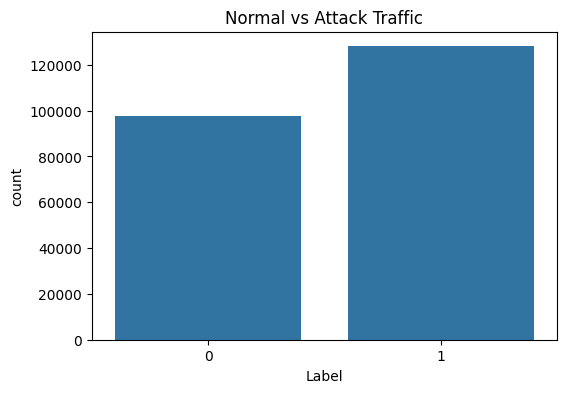

In [18]:
#Exploratory Data Analysis (EDA)
plt.figure(figsize=(6,4))
sns.countplot(x='Label', data=df)
plt.title("Normal vs Attack Traffic")
plt.show()


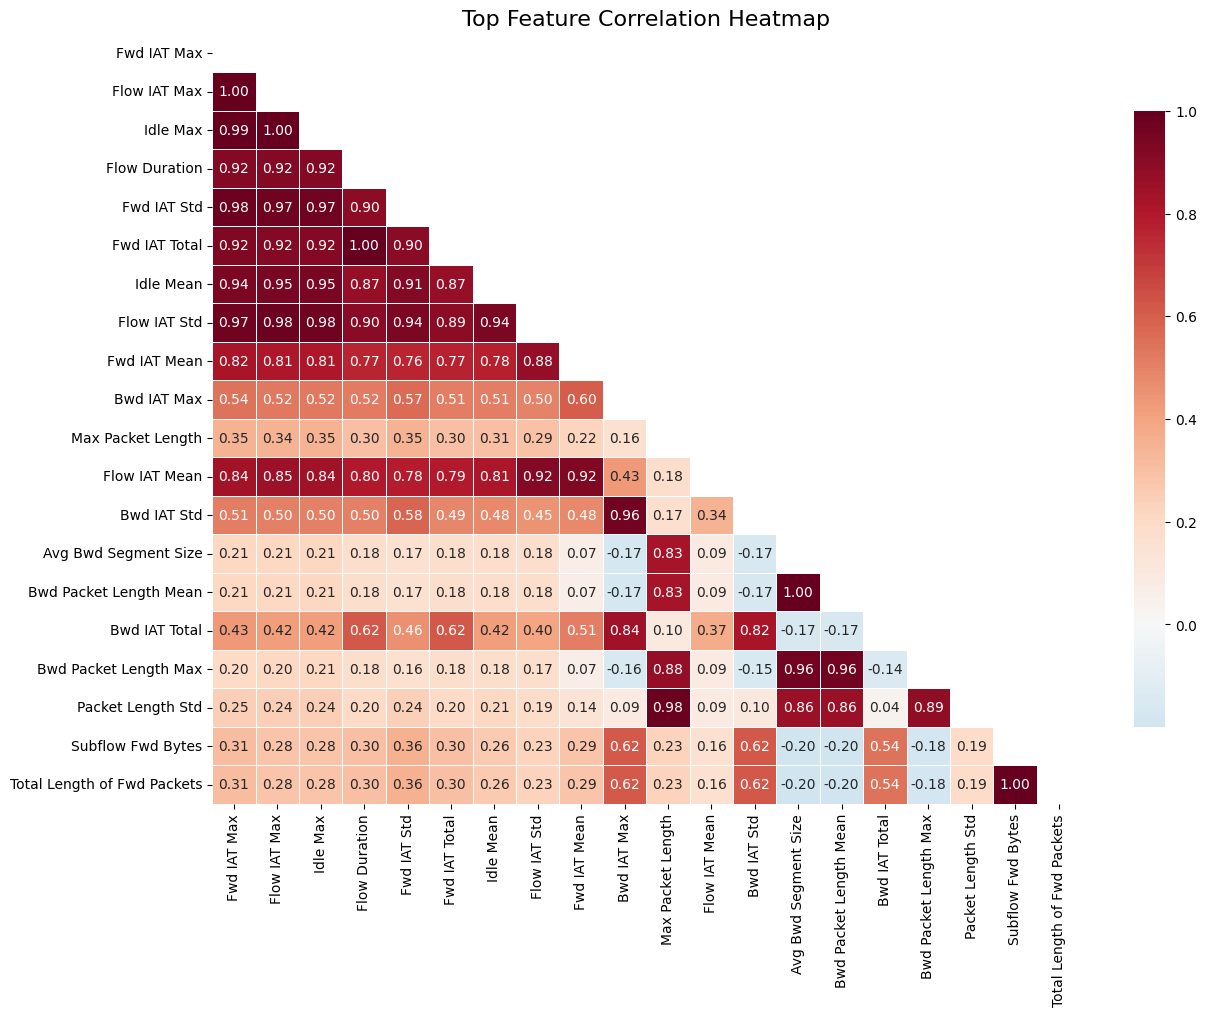

In [36]:


# Correlation
corr = df.corr()

# Top 20 most correlated features overall
top_features = corr.abs().mean().sort_values(ascending=False).head(20).index
corr_top = corr.loc[top_features, top_features]

# Mask upper triangle
mask = np.triu(np.ones_like(corr_top, dtype=bool))

plt.figure(figsize=(14,10))
sns.heatmap(
    corr_top,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)
plt.title("Top Feature Correlation Heatmap", fontsize=16)
plt.show()


In [37]:
#Feature Selection
X = df.drop('Label', axis=1)
y = df['Label']


In [38]:
# Use Extra Trees for feature importance
model = ExtraTreesClassifier(n_estimators=50, random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(20)

top_features


,0
URG Flag Count,0.079408
ACK Flag Count,0.072594
Bwd Packet Length Max,0.067337
Avg Bwd Segment Size,0.062383
Bwd Packet Length Mean,0.057755
Destination Port,0.050398
Average Packet Size,0.046418
Max Packet Length,0.028983
Bwd Packet Length Std,0.028612
Min Packet Length,0.026592


In [39]:
# Keep only top features
X = X[top_features.index]


In [40]:
#Handle Class Imbalance (SMOTE)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before:", y.value_counts())
print("After:", y_resampled.value_counts())


Before: Label
1    128025
0     97686
Name: count, dtype: int64
After: Label
0    128025
1    128025
Name: count, dtype: int64


In [41]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)


In [42]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [46]:
#Train Individual Models
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)


In [44]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


In [47]:
et = ExtraTreesClassifier(n_estimators=100, random_state=42)
et.fit(X_train, y_train)

et_pred = et.predict(X_test)


In [48]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:06:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [49]:
#Model Evaluation Function
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


In [50]:
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("Extra Trees", y_test, et_pred)
evaluate_model("XGBoost", y_test, xgb_pred)



Decision Tree
Accuracy: 0.9995703964069518
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25605
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     51210
   macro avg       1.00      1.00      1.00     51210
weighted avg       1.00      1.00      1.00     51210


Random Forest
Accuracy: 0.9996094512790471
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25605
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     51210
   macro avg       1.00      1.00      1.00     51210
weighted avg       1.00      1.00      1.00     51210


Extra Trees
Accuracy: 0.9996289787150947
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25605
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     5121

In [53]:
#Ensemble Model (Voting Classifier)
ensemble = VotingClassifier(
    estimators=[
        ('dt', dt),
        ('rf', rf),
        ('et', et),
        ('xgb', xgb)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)
ensemble_pred = ensemble.predict(X_test)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:10:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [52]:
evaluate_model("Ensemble Model", y_test, ensemble_pred)



Ensemble Model
Accuracy: 0.9996094512790471
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25605
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     51210
   macro avg       1.00      1.00      1.00     51210
weighted avg       1.00      1.00      1.00     51210



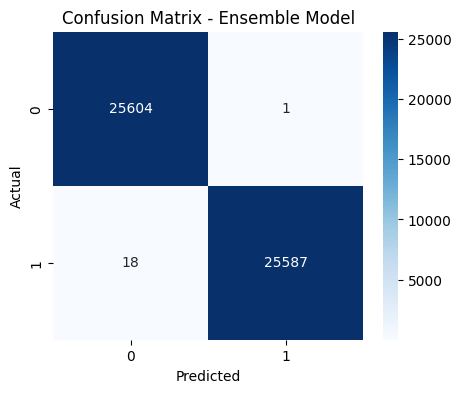

In [54]:
#Confusion Matrix Visualization
cm = confusion_matrix(y_test, ensemble_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ensemble Model")
plt.show()


In [56]:
# Training set score
train_score = ensemble.score(X_train, y_train)

# Test set score
test_score = ensemble.score(X_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.9997461433313806
Test Score: 0.9996289787150947


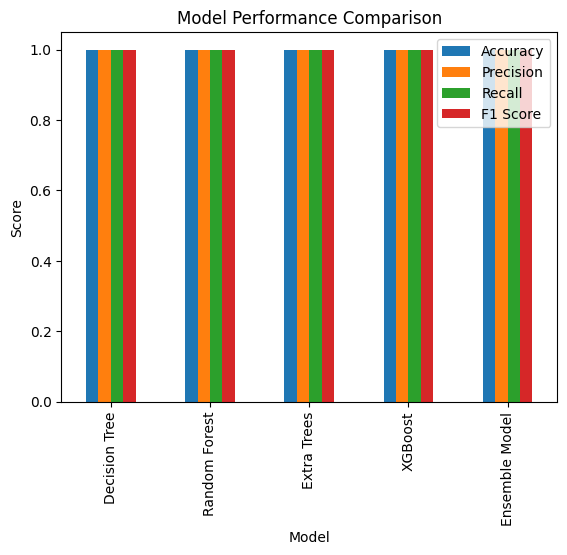

In [59]:
from sklearn.metrics import classification_report, accuracy_score

def get_metrics(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    accuracy = accuracy_score(y_true, y_pred)
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1 = report['weighted avg']['f1-score']
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}

# Collect metrics for each model
metrics = {}
metrics['Decision Tree'] = get_metrics(y_test, dt_pred)
metrics['Random Forest'] = get_metrics(y_test, rf_pred)
metrics['Extra Trees'] = get_metrics(y_test, et_pred)
metrics['XGBoost'] = get_metrics(y_test, xgb_pred)
metrics['Ensemble Model'] = get_metrics(y_test, ensemble_pred)

results_df = pd.DataFrame.from_dict(metrics, orient='index')
results_df.index.name = 'Model'

results_df[['Accuracy','Precision','Recall','F1 Score']].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.show()